# Fully-Online (Prequential) Just-In-Time Evaluation

This is the project's *true* protocol. Commits arrive one by one in chronological
order, and for **every** commit we, in order:

1. **Predict** its label using only the KG/history known so far;
2. **Evaluate** — reveal the true label and update running (cumulative + rolling)
   metrics;
3. **Grow** the KG state — the commit's relational/graph evidence is added
   (developer/file/global bug-rate counters advance; the graph used by
   PPR/embeddings includes it);
4. **Learn** — every model is updated with the now-known (features, label).

We run **within-project baselines** and **KG-native inference methods** in the
*same* stream, so they are compared under one identical online protocol.
(Engine: `inference/online_jit.py`. The earlier offline/blocked evaluations are
kept separately.)

In [1]:
import sys, os, pickle
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/'inference').exists() and ROOT != ROOT.parent: ROOT = ROOT.parent
os.chdir(ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi']=110

R = pickle.load(open('outputs/online_jit_results.pkl','rb'))
meta = R['meta']
print(f"streamed commits={meta['N']-meta['warmup']} (warmup {meta['warmup']}), "
      f"stream bug-rate={meta['stream_bug']:.3f}")

streamed commits=5642 (warmup 2417), stream bug-rate=0.241


## 1. Final prequential comparison (cumulative over the whole stream)

**`F1_online` is the headline operating-point metric** — the buggy-class F1 with
the decision threshold tuned *online* on past data only (re-tuned every 150
commits). It answers the practical JIT question (do we actually catch bugs at a
usable precision?), where plain F1@0.5 is unfair to uncalibrated scores. We sort
by it; PR-AUC / ROC-AUC are reported as threshold-free ranking metrics.

In [3]:
rows=[]
for m,d in R['methods'].items():
    rows.append(dict(method=d['name'], group=d['group'], **d['cum']))
df=pd.DataFrame(rows).set_index('method')
df=df[['group','F1_online','F1','PR_AUC','ROC_AUC','MCC','Brier']].sort_values('F1_online',ascending=False)
df.round(3)

,group,F1_online,F1,PR_AUC,ROC_AUC,MCC,Brier
method,,,,,,,
Fusion (metrics+priors+TFIDF+PPR),kg,0.593,0.552,0.598,0.822,0.395,0.225
Personalized PageRank,kg,0.511,0.512,0.383,0.727,0.322,0.220
Structural TF-IDF (incremental),kg,0.490,0.486,0.420,0.719,0.284,0.333
GradBoost / JIT metrics,baseline,0.481,0.445,0.469,0.711,0.296,0.179
KG embedding (SVD/LSA),kg,0.479,0.460,0.427,0.690,0.288,0.220
RandomForest / JIT metrics,baseline,0.478,0.240,0.478,0.723,0.237,0.162
Relational priors (wvRN),kg,0.477,0.048,0.428,0.703,0.097,0.166
LR / JIT metrics (incremental),baseline,0.464,0.467,0.348,0.671,0.246,0.427
Naive prior bug-rate,baseline,0.391,0.000,0.223,0.468,0.000,0.188


## 2. The headline metrics — online buggy-F1 and PR-AUC
Baselines (orange) vs KG-native methods (blue). **Left = `F1_online`** (the
deployment metric); right = PR-AUC. Dashed line = random.

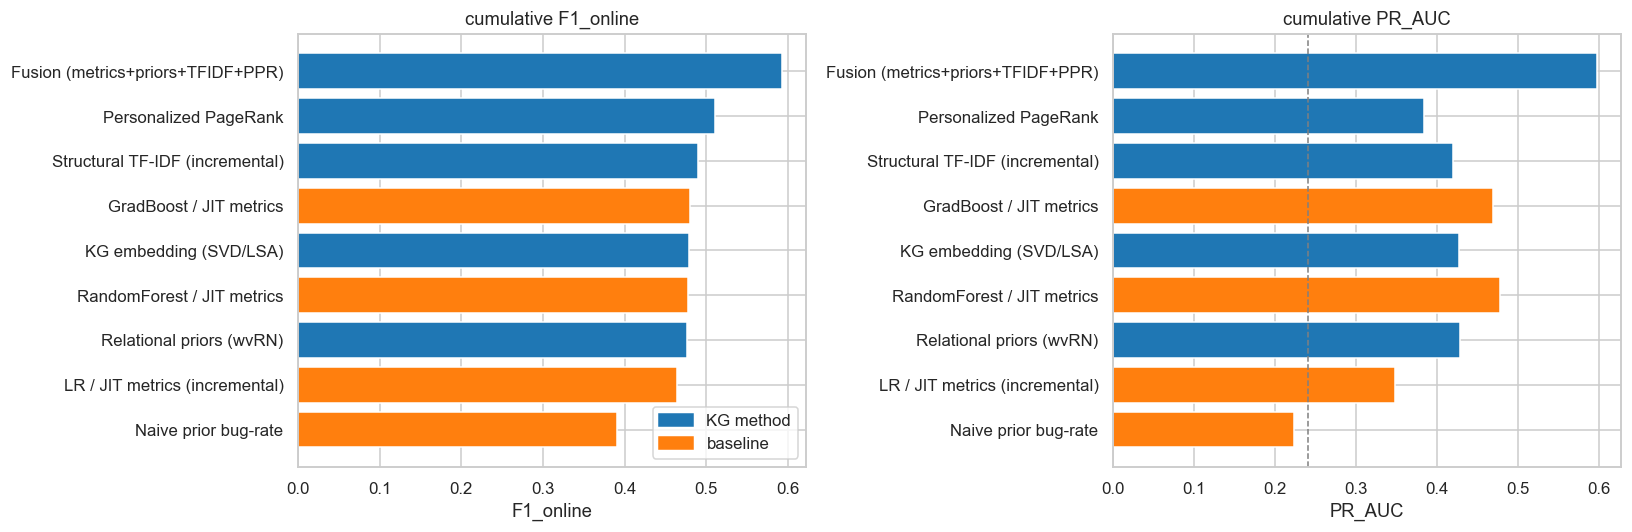

In [4]:
order=df.sort_values('F1_online',ascending=False).index.tolist()
gof={d['name']:d['group'] for d in R['methods'].values()}
colors=['#1f77b4' if gof[m]=='kg' else '#ff7f0e' for m in order]
fig,ax=plt.subplots(1,2,figsize=(15,5))
for a,metric,rnd in [(ax[0],'F1_online',None),(ax[1],'PR_AUC',meta['stream_bug'])]:
    a.barh(range(len(order)),[df.loc[m,metric] for m in order],color=colors)
    a.set_yticks(range(len(order))); a.set_yticklabels(order); a.invert_yaxis()
    if rnd is not None: a.axvline(rnd,ls='--',c='gray',lw=1)
    a.set_title(f'cumulative {metric}'); a.set_xlabel(metric)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color='#1f77b4',label='KG method'),Patch(color='#ff7f0e',label='baseline')],loc='lower right')
plt.tight_layout(); plt.show()

## 3. Online evaluation *as commits arrive* — rolling-window metric trajectories
This is the heart of the JIT protocol: the metric is recomputed over a moving
window as the stream advances, so we see performance evolve (and drift) over the
project's history.

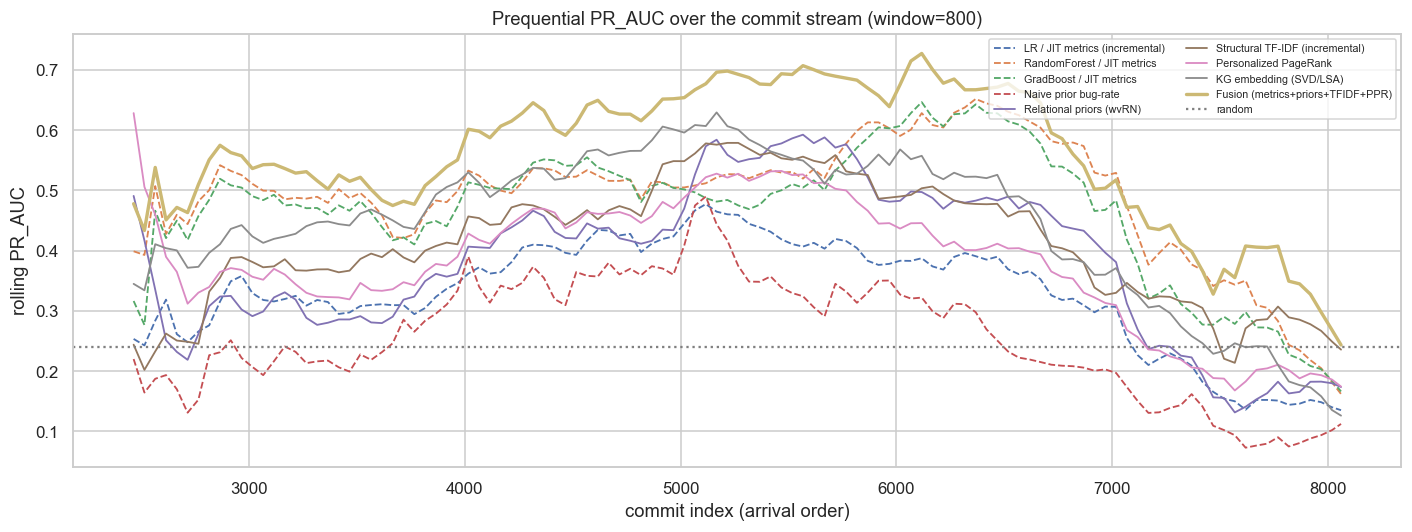

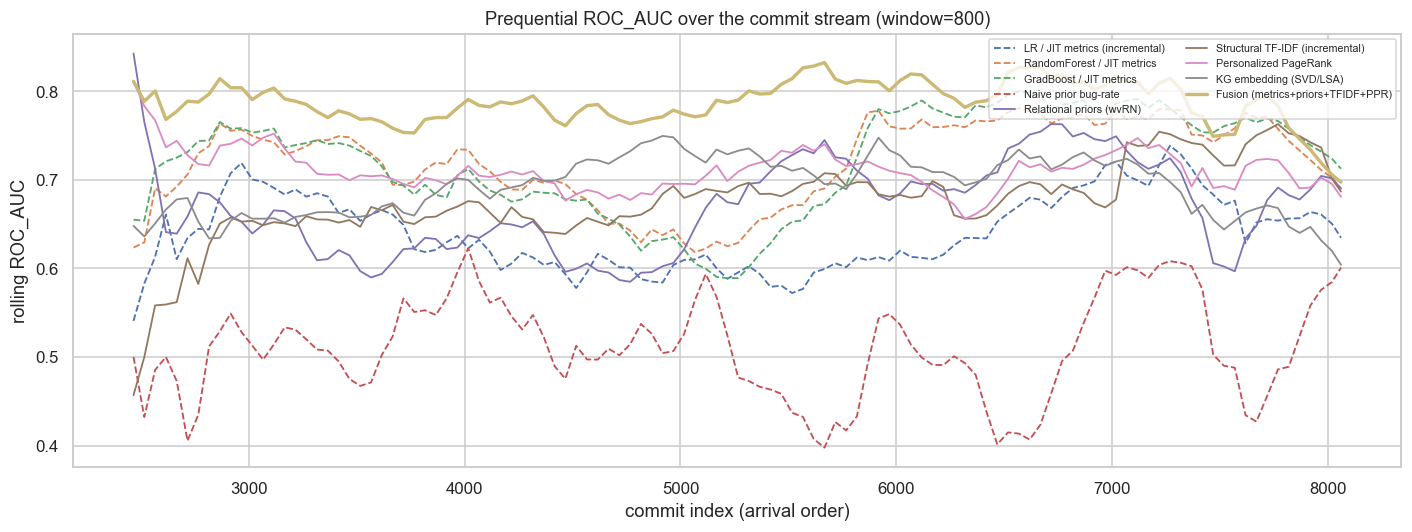

In [5]:
def plot_traj(metric):
    fig,ax=plt.subplots(figsize=(13,5))
    for m,d in R['methods'].items():
        t=R['traj'][m]; style='-' if d['group']=='kg' else '--'
        lw=2.2 if m=='K_fusion' else 1.2
        ax.plot(t['idx'], t[metric], style, lw=lw, label=d['name'])
    if metric=='PR_AUC': ax.axhline(meta['stream_bug'],ls=':',c='gray',label='random')
    ax.set_xlabel('commit index (arrival order)'); ax.set_ylabel(f'rolling {metric}')
    ax.set_title(f'Prequential {metric} over the commit stream (window=800)')
    ax.legend(fontsize=7,ncol=2,loc='upper right'); plt.tight_layout(); plt.show()
plot_traj('PR_AUC'); plot_traj('ROC_AUC')

## 4. Fusion vs the best baseline, over time
Solid = KG Fusion; dashed = the strongest JIT-metrics baseline. Shows whether the
KG advantage holds *throughout* the stream or only in places.

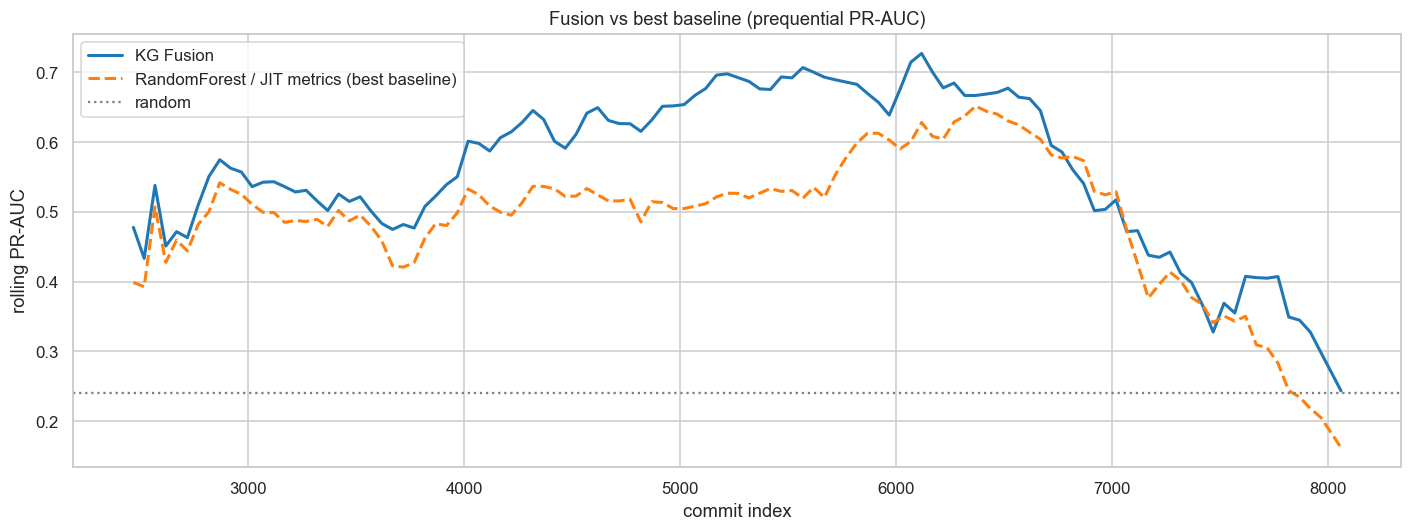

Final cumulative PR-AUC:  Fusion=0.598   best baseline (RandomForest / JIT metrics)=0.478


In [6]:
base_methods=[k for k,v in R['methods'].items() if v['group']=='baseline' and k!='B_naive_rate']
best_base=max(base_methods,key=lambda k:R['methods'][k]['cum']['PR_AUC'])
fig,ax=plt.subplots(figsize=(13,5))
for k,lab,st,c in [('K_fusion','KG Fusion','-','#1f77b4'),(best_base,R['methods'][best_base]['name']+' (best baseline)','--','#ff7f0e')]:
    ax.plot(R['traj'][k]['idx'],R['traj'][k]['PR_AUC'],st,lw=2,color=c,label=lab)
ax.axhline(meta['stream_bug'],ls=':',c='gray',label='random')
ax.set(xlabel='commit index',ylabel='rolling PR-AUC',title='Fusion vs best baseline (prequential PR-AUC)')
ax.legend(); plt.tight_layout(); plt.show()
print('Final cumulative PR-AUC:  Fusion=%.3f   best baseline (%s)=%.3f'
      % (R['methods']['K_fusion']['cum']['PR_AUC'], R['methods'][best_base]['name'], R['methods'][best_base]['cum']['PR_AUC']))

## 5. Fusion feature ablation (online)

The **Fusion** combines four feature streams:
**M** = JIT metrics, **T** = structural TF-IDF, **R** = relational priors,
**P** = PPR score, **X** = commit-message text (V2). To measure each one's
importance we evaluate **all 31 non-empty subsets** (1..5 features) under the
*same* fully-online prequential protocol — a balanced logistic regression
retrained on the expanding past window over the selected features.

The five feature streams are precomputed once (the priors-growth and per-block
PPR are identical regardless of the subset), so the 31 runs are cheap.

In [8]:
import sys; sys.path.insert(0, str(ROOT/'inference'))
import online_jit as oj
S = oj.precompute_streams()          # cached -> outputs/online_jit_streams_v2.pkl
ABL = oj.ablation_all(S)             # all 31 subsets, online prequential
FULL = '+'.join(oj.FEAT_ABBR[f] for f in oj.FEATURES)   # 'M+T+R+P+X'
adf = pd.DataFrame([
    dict(combo=k, n_features=v['n'], **{m: v['cum'][m] for m in ['F1_online','F1','PR_AUC','ROC_AUC','MCC']})
    for k,v in ABL.items()
]).set_index('combo').sort_values('F1_online', ascending=False)
print('M=JIT metrics  T=structural TF-IDF  R=relational priors  P=PPR score  X=commit text')
print('(F1_online = buggy-F1 with online-tuned threshold = the operating-point metric)')
adf.round(3)

M=JIT metrics  T=structural TF-IDF  R=relational priors  P=PPR score  X=commit text
(F1_online = buggy-F1 with online-tuned threshold = the operating-point metric)


,n_features,F1_online,F1,PR_AUC,ROC_AUC,MCC
combo,,,,,,
M+T+R,3,0.604,0.561,0.608,0.828,0.410
M+T+R+P,4,0.601,0.563,0.606,0.828,0.412
M+T+R+P+X,5,0.597,0.584,0.610,0.830,0.438
M+T+R+X,4,0.593,0.581,0.610,0.829,0.434
T+R+P+X,4,0.591,0.571,0.606,0.823,0.416
T+R+P,3,0.589,0.554,0.600,0.821,0.397
T+R+X,3,0.589,0.570,0.606,0.823,0.416
T+R,2,0.586,0.551,0.600,0.821,0.394
M+R+P+X,4,0.571,0.564,0.576,0.814,0.407


### 5a. All 31 combinations ranked — online buggy-F1 and PR-AUC
Bars coloured by how many features the combination uses. **Left = `F1_online`**
(operating point); right = PR-AUC (ranking).

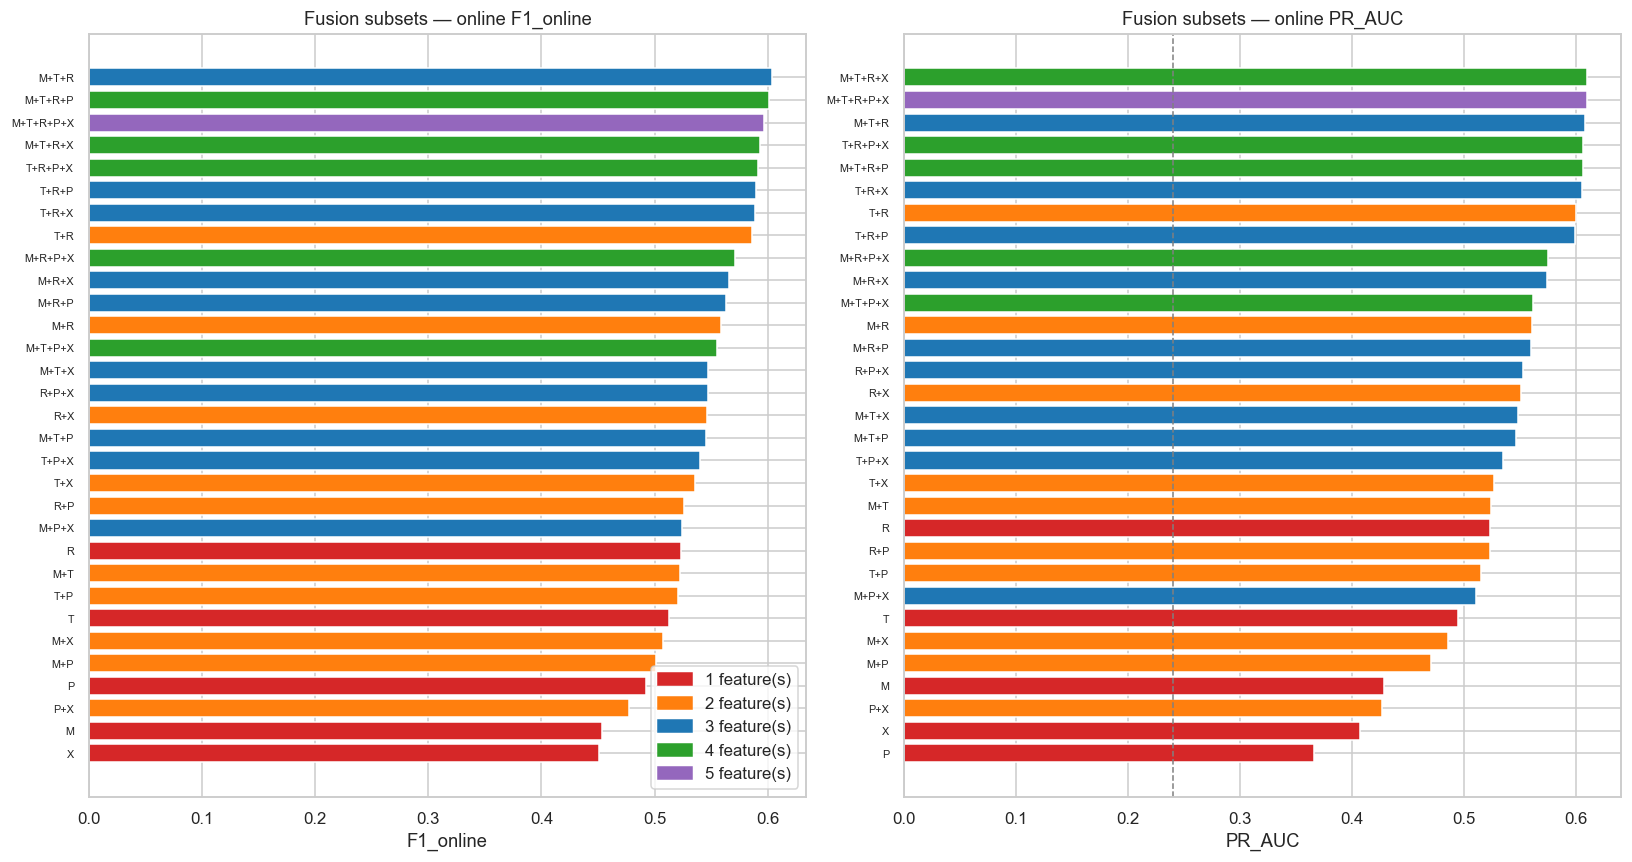

In [9]:
cmap = {1:'#d62728', 2:'#ff7f0e', 3:'#1f77b4', 4:'#2ca02c', 5:'#9467bd'}
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
for a, metric in [(ax[0],'F1_online'), (ax[1],'PR_AUC')]:
    order = adf.sort_values(metric, ascending=True).index.tolist()
    colors = [cmap[adf.loc[c,'n_features']] for c in order]
    a.barh(range(len(order)), [adf.loc[c,metric] for c in order], color=colors)
    a.set_yticks(range(len(order))); a.set_yticklabels(order, fontsize=7)
    a.set_xlabel(metric); a.set_title(f'Fusion subsets — online {metric}')
ax[1].axvline(S['y'][S['W']:].mean(), ls='--', c='gray', lw=1)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=cmap[k], label=f'{k} feature(s)') for k in [1,2,3,4,5]], loc='lower right')
plt.tight_layout(); plt.show()

### 5b. Single-feature strength and leave-one-out importance (by online F1)
*Left:* each feature alone. *Right:* the drop in `F1_online` when each feature is
removed from the full M+T+R+P+X fusion (bigger drop = more important / less
redundant; a negative bar means the feature slightly *hurts*).

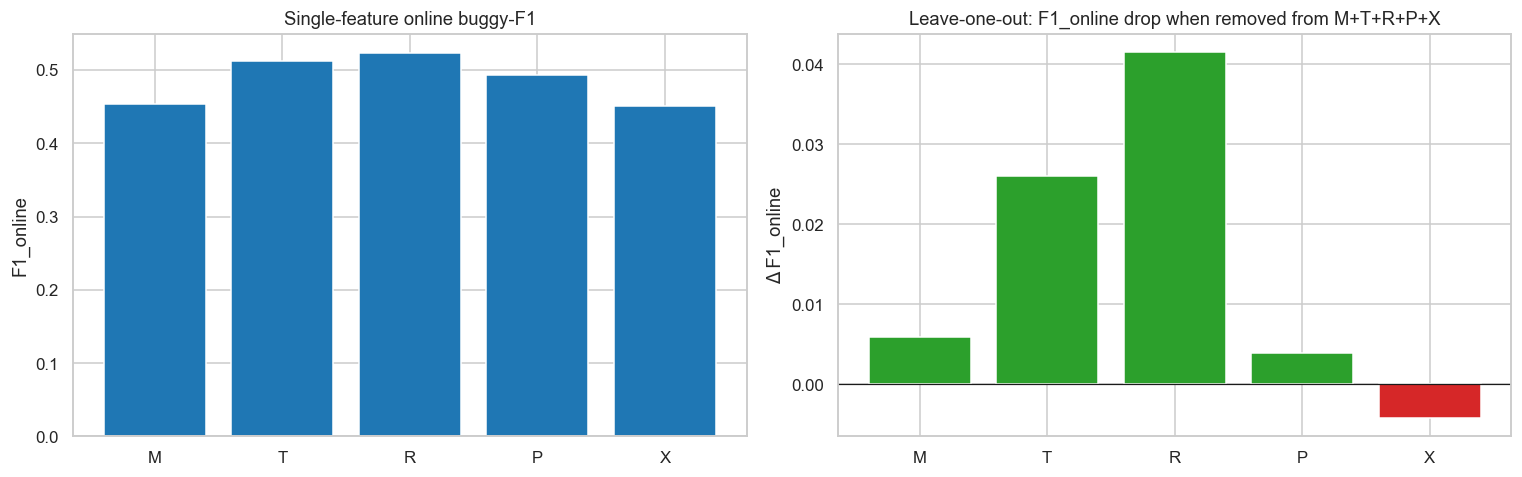

Full M+T+R+P+X  F1_online = 0.597  PR-AUC = 0.61
Single-feature F1_online: {'M': 0.453, 'T': 0.513, 'R': 0.523, 'P': 0.493, 'X': 0.451}
Leave-one-out drop      : {'M': 0.006, 'T': 0.026, 'R': 0.042, 'P': 0.004, 'X': -0.004}


In [10]:
MET='F1_online'
singles = {oj.FEAT_ABBR[f]: ABL[oj.FEAT_ABBR[f]]['cum'] for f in oj.FEATURES}
full = ABL[FULL]['cum'][MET]
loo = {}
for f in oj.FEATURES:
    rest = '+'.join(oj.FEAT_ABBR[g] for g in oj.FEATURES if g!=f)
    loo[oj.FEAT_ABBR[f]] = full - ABL[rest]['cum'][MET]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(list(singles), [v[MET] for v in singles.values()], color='#1f77b4')
ax[0].set_title('Single-feature online buggy-F1'); ax[0].set_ylabel('F1_online')
ax[1].bar(list(loo), list(loo.values()), color=['#2ca02c' if v>=0 else '#d62728' for v in loo.values()])
ax[1].axhline(0, c='k', lw=0.8)
ax[1].set_title(f'Leave-one-out: F1_online drop when removed from {FULL}'); ax[1].set_ylabel('Δ F1_online')
plt.tight_layout(); plt.show()
print(f'Full {FULL}  F1_online =', round(full,3), ' PR-AUC =', round(ABL[FULL]['cum']['PR_AUC'],3))
print('Single-feature F1_online:', {k: round(v[MET],3) for k,v in singles.items()})
print('Leave-one-out drop      :', {k: round(v,3) for k,v in loo.items()})

### 5c. Trajectories — singles vs full fusion over the stream

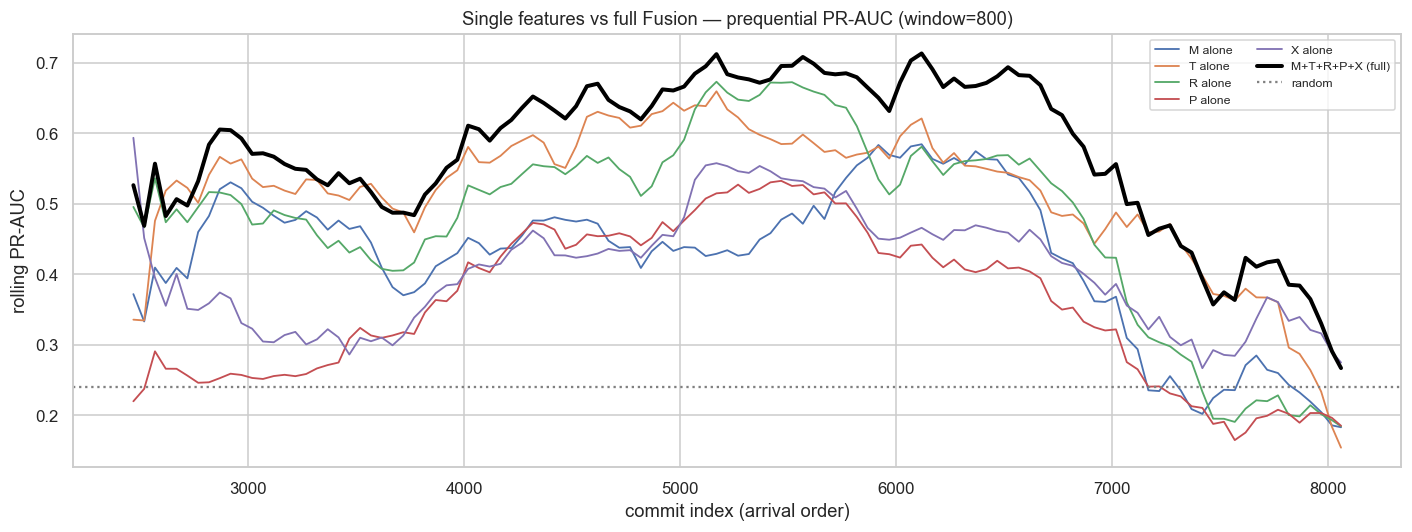

In [11]:
fig, ax = plt.subplots(figsize=(13,5))
for f in oj.FEATURES:
    t = ABL[oj.FEAT_ABBR[f]]['traj']; ax.plot(t['idx'], t['PR_AUC'], lw=1.2, label=oj.FEAT_ABBR[f]+' alone')
t = ABL[FULL]['traj']; ax.plot(t['idx'], t['PR_AUC'], lw=2.6, color='black', label=FULL+' (full)')
ax.axhline(S['y'][S['W']:].mean(), ls=':', c='gray', label='random')
ax.set(xlabel='commit index (arrival order)', ylabel='rolling PR-AUC',
       title='Single features vs full Fusion — prequential PR-AUC (window=800)')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

### 5d. Reading the ablation (V2)
- **X (commit text)** is the weakest single feature online and does not raise the
  top of the ranking: **M+T+R** stays best on `F1_online`.
- **Single-feature** bars rank the standalone strength of each signal.
- **Leave-one-out** is the cleanest importance measure: a large drop when a
  feature is removed means it carries information the others do not; a near-zero
  or negative bar means it is redundant (PPR and, online, the simple text TF-IDF).

## 6. Baselines vs. KG-v1 vs. KG-v2 — online buggy-F1

Sections 1–5 compared methods *within* a family (baselines together, or the Fusion
subsets together). This puts **all three families on one axis** under the same
fully-online protocol: the within-project **baselines** (JIT metrics only), the
**KG-v1** inference methods (no commit-text), and the **KG-v2** methods (+ commit-text
stream `X`). The headline metric is the **online buggy-F1** (`F1_online`); PR-AUC is shown
alongside.

Single methods + baselines come from the streaming engine (`R = online_jit_results.pkl`);
the three Fusion bars come from the unified ablation (`ABL`), so the V1 (M+T+R+P) vs V2
(M+T+R+P+X, M+T+R) fusion deltas are produced by one engine and are directly comparable.
This is the same figure as `docs/figures/v1_v2_baseline_f1.png`.

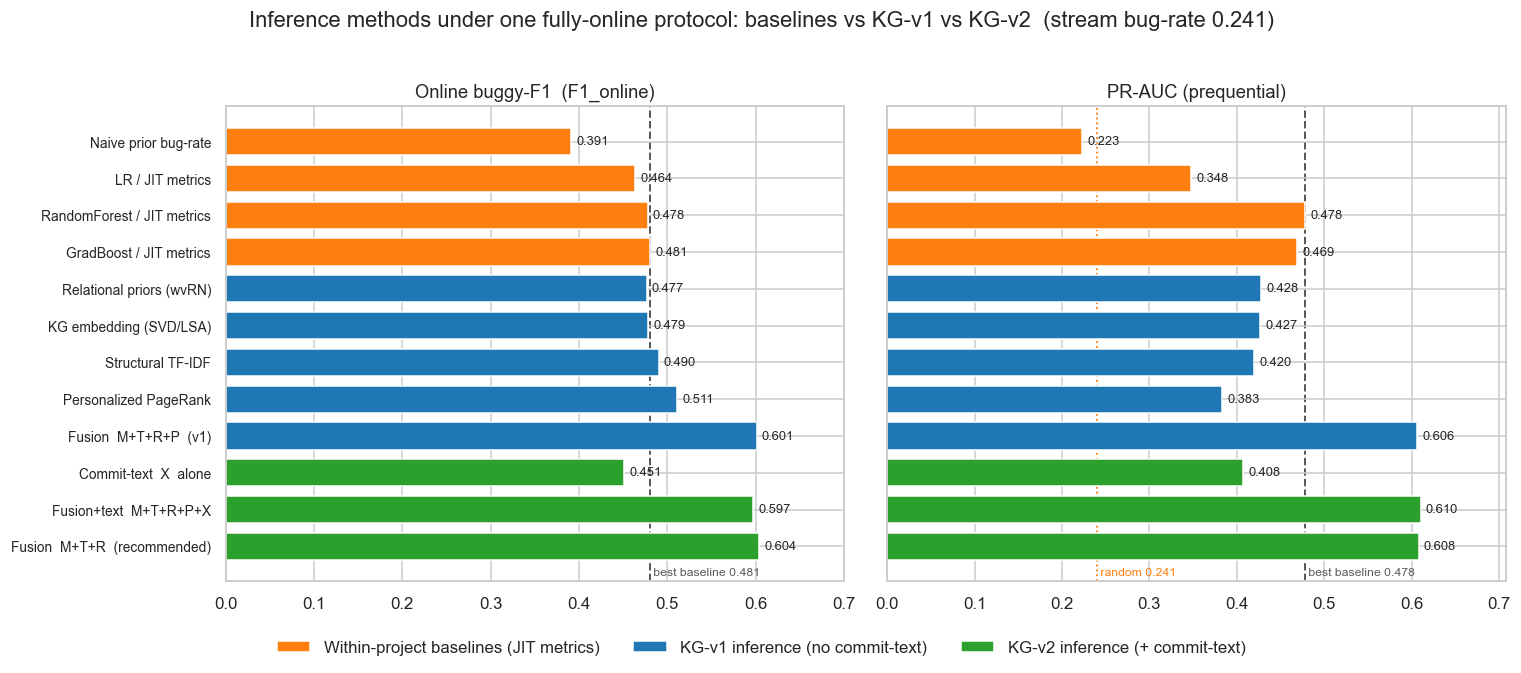

Best baseline F1_online = 0.481 (GradBoost);  KG-v1 Fusion = 0.601;  KG-v2 M+T+R = 0.604


In [12]:
from matplotlib.patches import Patch
KGBLUE, KGGREEN, KGORANGE = "#1F77B4", "#2CA02C", "#FF7F0E"

M = {v["name"]: v["cum"] for v in R["methods"].values()}
g = lambda name:  (M[name]["F1_online"], M[name]["PR_AUC"])         # streaming engine
a = lambda label: (ABL[label]["cum"]["F1_online"], ABL[label]["cum"]["PR_AUC"])  # ablation

ROWS = [
    ("Naive prior bug-rate",         g("Naive prior bug-rate"),            "base"),
    ("LR / JIT metrics",             g("LR / JIT metrics (incremental)"),  "base"),
    ("RandomForest / JIT metrics",   g("RandomForest / JIT metrics"),      "base"),
    ("GradBoost / JIT metrics",      g("GradBoost / JIT metrics"),         "base"),
    ("Relational priors (wvRN)",     g("Relational priors (wvRN)"),        "v1"),
    ("KG embedding (SVD/LSA)",       g("KG embedding (SVD/LSA)"),          "v1"),
    ("Structural TF-IDF",            g("Structural TF-IDF (incremental)"), "v1"),
    ("Personalized PageRank",        g("Personalized PageRank"),           "v1"),
    ("Fusion  M+T+R+P  (v1)",        a("M+T+R+P"),                         "v1"),
    ("Commit-text  X  alone",        a("X"),                               "v2"),
    ("Fusion+text  M+T+R+P+X",       a("M+T+R+P+X"),                       "v2"),
    ("Fusion  M+T+R  (recommended)", a("M+T+R"),                           "v2"),
]
COLOR  = {"base": KGORANGE, "v1": KGBLUE, "v2": KGGREEN}
LEGEND = {"base": "Within-project baselines (JIT metrics)",
          "v1":   "KG-v1 inference (no commit-text)",
          "v2":   "KG-v2 inference (+ commit-text)"}

order  = ([r for r in ROWS if r[2]=="base"] + [r for r in ROWS if r[2]=="v1"]
          + [r for r in ROWS if r[2]=="v2"])
labels = [r[0] for r in order]
f1 = np.array([r[1][0] for r in order]); pr = np.array([r[1][1] for r in order])
colors = [COLOR[r[2]] for r in order]; y = np.arange(len(order))
best_f1 = max(r[1][0] for r in ROWS if r[2]=="base")
best_pr = max(r[1][1] for r in ROWS if r[2]=="base")
stream_bug = R["meta"]["stream_bug"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, vals, title, ref in [(axes[0], f1, "Online buggy-F1  (F1_online)", best_f1),
                             (axes[1], pr, "PR-AUC (prequential)",         best_pr)]:
    ax.barh(y, vals, color=colors, edgecolor="white", height=0.74)
    ax.axvline(ref, ls="--", lw=1.3, color="0.35", zorder=0)
    ax.text(ref, len(order)-0.3, f" best baseline {ref:.3f}", color="0.35", fontsize=8, va="center")
    for yi, v in zip(y, vals): ax.text(v+0.006, yi, f"{v:.3f}", va="center", fontsize=8.5)
    ax.set_xlim(0, vals.max()*1.16); ax.set_title(title); ax.set_axisbelow(True)
axes[1].axvline(stream_bug, ls=":", lw=1.2, color=KGORANGE, zorder=0)
axes[1].text(stream_bug, len(order)-0.3, f" random {stream_bug:.3f}", color=KGORANGE, fontsize=8, va="center")
axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=9); axes[0].invert_yaxis()
fig.legend(handles=[Patch(facecolor=COLOR[k], label=LEGEND[k]) for k in ("base","v1","v2")],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Inference methods under one fully-online protocol: baselines vs KG-v1 vs KG-v2"
             f"  (stream bug-rate {stream_bug:.3f})")
plt.tight_layout(rect=[0, 0.04, 1, 0.96]); plt.show()

print("Best baseline F1_online = %.3f (GradBoost);  KG-v1 Fusion = %.3f;  KG-v2 M+T+R = %.3f"
      % (best_f1, ABL["M+T+R+P"]["cum"]["F1_online"], ABL["M+T+R"]["cum"]["F1_online"]))

## 8. Commit Semantic-Text Graph (CSTG)

The **CSTG** models each commit's *text* (message + diff) as a first-class graph, alongside the AST and delta graphs: Graph-of-Words **TW-IDF**, an **NPMI** term co-occurrence graph, **defect-typed** terms (code / bug / action / error / nl), and cross-modal **grounding** to AST identifiers / files. On the controlled split (matched RF) it **beats the strongest text baseline** (diff-text TF-IDF-768). Below: the validated comparison, the term co-occurrence graph, and the most bug-predictive terms. (Fit via `inference/cstg.py`, cached to `outputs/cstg_bundle.pkl`.)

CSTG: 19,669 Term nodes | 5,277,033 NPMI edges


,ROC,PR-AUC,F1,Popt,ACC@20
method,,,,,
JIT metrics,0.712,0.222,0.180,0.776,0.516
diff-text TF-IDF-768 (baseline),0.786,0.280,0.347,0.815,0.637
CSTG TW-IDF,0.817,0.296,0.391,0.833,0.648
CSTG full,0.821,0.302,0.402,0.835,0.659
JIT + CSTG,0.827,0.314,0.390,0.840,0.670


published diff-text TF-IDF-768D RF baseline: ROC 0.813 | F1 0.321


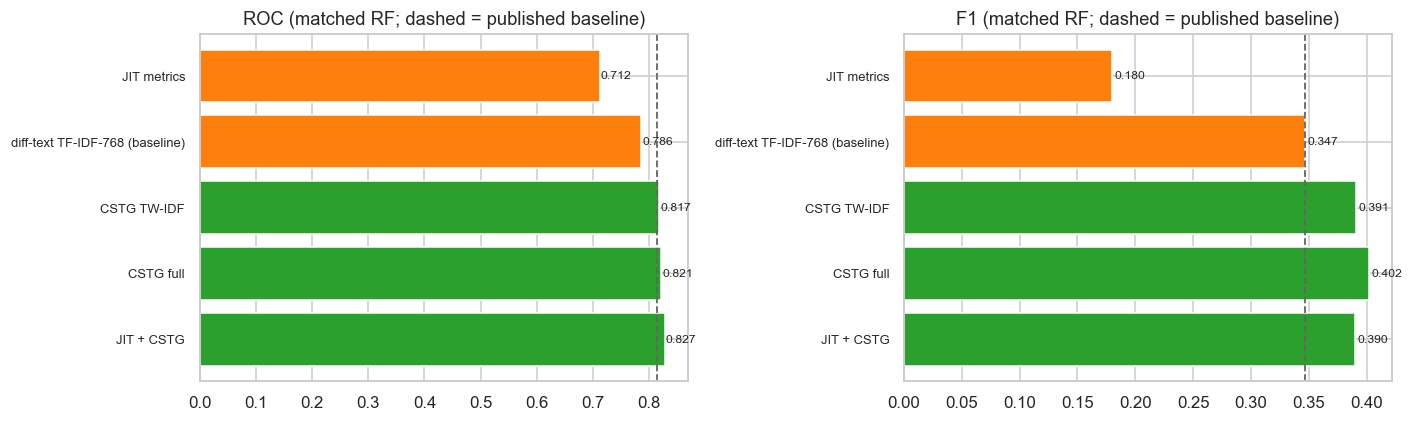

In [7]:
import sys, pickle
sys.path.insert(0, str(ROOT/'inference'))
import cstg as _C   # so the pickled CSTG class resolves
cs, B = pickle.load(open(ROOT/'outputs/cstg_bundle.pkl','rb'))
print(f"CSTG: {len(cs.vocab):,} Term nodes | {sum(len(v) for v in cs.npmi.values())//2:,} NPMI edges")

perf = pd.DataFrame([
    ('JIT metrics',0.712,0.222,0.180,0.776,0.516,'base'),
    ('diff-text TF-IDF-768 (baseline)',0.786,0.280,0.347,0.815,0.637,'base'),
    ('CSTG TW-IDF',0.817,0.296,0.391,0.833,0.648,'cstg'),
    ('CSTG full',0.821,0.302,0.402,0.835,0.659,'cstg'),
    ('JIT + CSTG',0.827,0.314,0.390,0.840,0.670,'cstg'),
], columns=['method','ROC','PR-AUC','F1','Popt','ACC@20','grp']).set_index('method')
display(perf.drop(columns='grp').round(3))
print('published diff-text TF-IDF-768D RF baseline: ROC 0.813 | F1 0.321')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, m, ref in [(ax[0], 'ROC', 0.813), (ax[1], 'F1', 0.347)]:
    col = ['#FF7F0E' if g=='base' else '#2CA02C' for g in perf['grp']]
    a.barh(range(len(perf)), perf[m], color=col, edgecolor='white')
    a.axvline(ref, ls='--', c='.4', lw=1.2)
    for i, v in enumerate(perf[m]): a.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=8)
    a.set_yticks(range(len(perf))); a.set_yticklabels(perf.index, fontsize=8.5)
    a.invert_yaxis(); a.set_title(m + ' (matched RF; dashed = published baseline)')
plt.tight_layout(); plt.show()

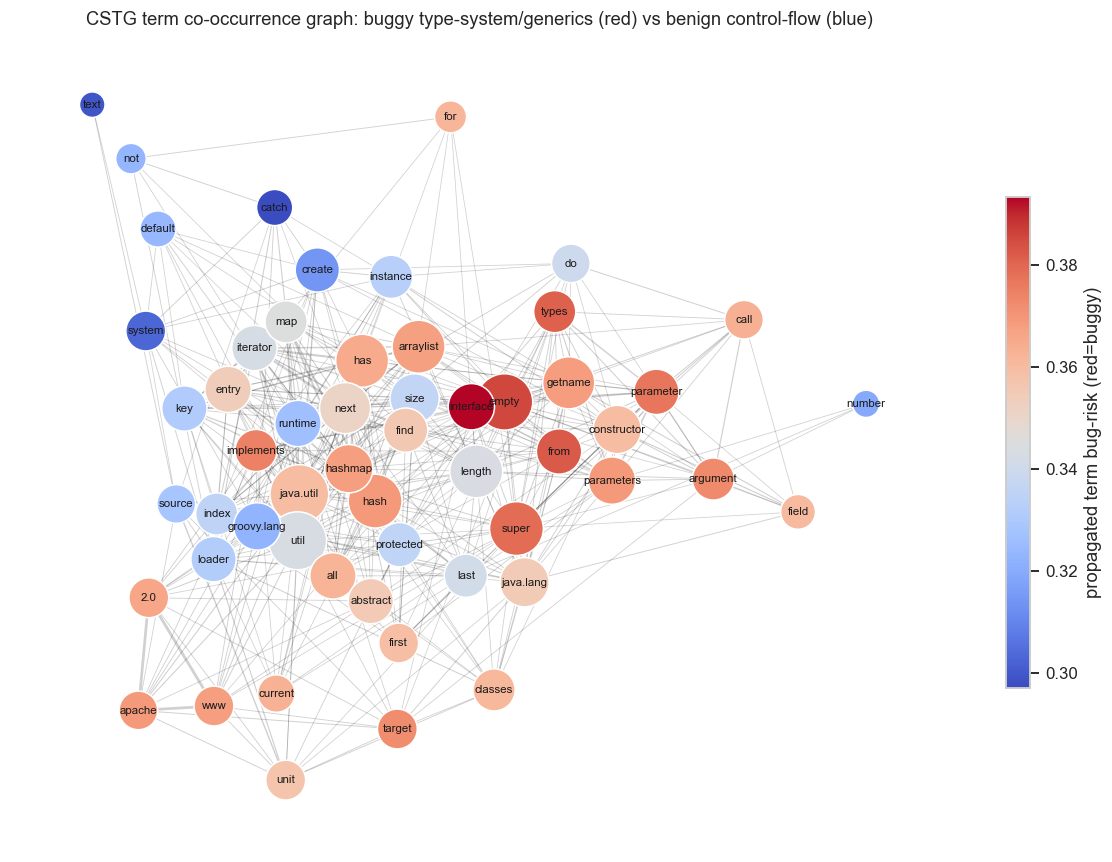

In [8]:
# CSTG term co-occurrence (NPMI) graph, coloured by propagated bug-risk
import networkx as nx
deg = {t: len(cs.npmi.get(t, [])) for t in cs.vocab if t in cs.npmi}
cand = [t for t in sorted(deg, key=lambda t:-deg[t]) if len(t) <= 22][:55]
S = set(cand); G = nx.Graph()
for t in cand:
    G.add_node(t, risk=cs.term_risk[t])
    for u, w in cs.npmi.get(t, ()):
        if u in S and w >= 0.25: G.add_edge(t, u, w=w)
G.remove_nodes_from([n for n in list(G) if G.degree(n)==0])
pos = nx.spring_layout(G, k=0.6, seed=3, weight='w')
risks = np.array([G.nodes[n]['risk'] for n in G])
fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(G, pos, alpha=0.2, width=[G[u][v]['w']*2 for u,v in G.edges], ax=ax)
nd = nx.draw_networkx_nodes(G, pos, node_color=risks, cmap='coolwarm', vmin=risks.min(), vmax=risks.max(),
                            node_size=[200+40*G.degree(n) for n in G], edgecolors='white', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7.5, ax=ax)
fig.colorbar(nd, ax=ax, shrink=0.6, label='propagated term bug-risk (red=buggy)')
ax.set_title('CSTG term co-occurrence graph: buggy type-system/generics (red) vs benign control-flow (blue)')
ax.axis('off'); plt.tight_layout(); plt.show()

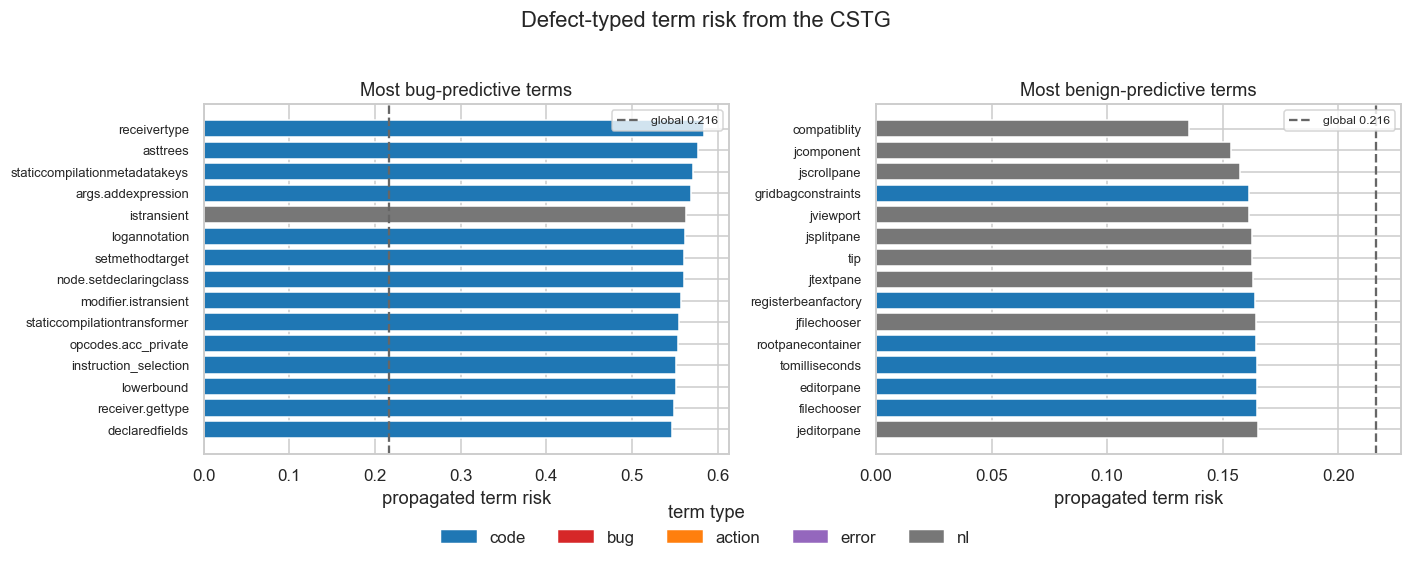

In [9]:
# most bug- / benign-predictive defect-typed terms (NPMI-propagated, train-only)
from matplotlib.patches import Patch
g0 = cs.global_rate
items = [(t, cs.term_risk[t], cs.ttype[t]) for t in cs.vocab]
risky = sorted(items, key=lambda x:-x[1])[:15]; safe = sorted(items, key=lambda x:x[1])[:15]
TC = {'code':'#1F77B4','bug':'#D62728','action':'#FF7F0E','error':'#9467BD','nl':'#777777'}
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, data, title in [(ax[0], risky, 'Most bug-predictive terms'), (ax[1], safe, 'Most benign-predictive terms')]:
    a.barh(range(len(data)), [d[1] for d in data], color=[TC[d[2]] for d in data], edgecolor='white')
    a.axvline(g0, ls='--', c='.4', label=f'global {g0:.3f}')
    a.set_yticks(range(len(data))); a.set_yticklabels([d[0] for d in data], fontsize=8.5)
    a.invert_yaxis(); a.set_title(title); a.set_xlabel('propagated term risk'); a.legend(fontsize=8)
fig.legend(handles=[Patch(color=c,label=k) for k,c in TC.items()], loc='lower center',
           ncol=5, frameon=False, bbox_to_anchor=(0.5,-0.02), title='term type')
plt.suptitle('Defect-typed term risk from the CSTG'); plt.tight_layout(rect=[0,0.04,1,0.96]); plt.show()

### 8a. Online CSTG (prequential, JIT/commit-level)

The CSTG run the way it deploys: **predict-then-grow at each commit arrival, strictly past-only** (`inference/online_cstg.py`). Adding the CSTG to the JIT metrics online lifts ROC 0.660->0.800, PR-AUC 0.340->0.552, F1_online 0.471->0.556, Popt 0.726->0.852.

,ROC,PR,F1_online,Popt,ACC20
JIT metrics,0.660,0.340,0.471,0.726,0.557
CSTG text,0.643,0.321,0.438,0.827,0.593
CSTG term-risk prior,0.605,0.345,0.400,0.833,0.604
JIT + CSTG (Fusion),0.800,0.552,0.556,0.852,0.636


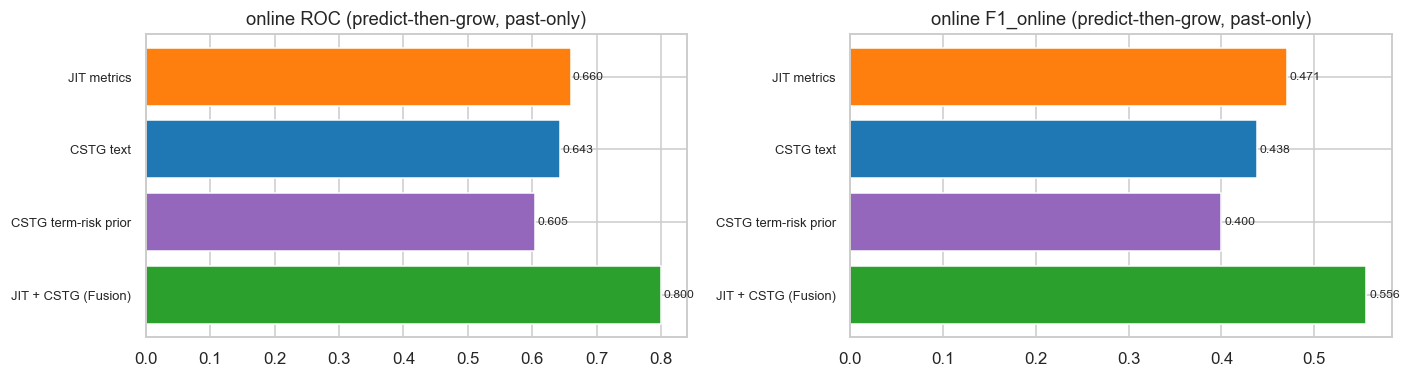

In [10]:
import pickle
R = pickle.load(open(ROOT/'outputs/online_cstg_results.pkl','rb'))
od = pd.DataFrame(R).T[['ROC','PR','F1_online','Popt','ACC20']]
od.index = ['JIT metrics','CSTG text','CSTG term-risk prior','JIT + CSTG (Fusion)']
display(od.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, m in [(ax[0],'ROC'), (ax[1],'F1_online')]:
    col = ['#FF7F0E','#1F77B4','#9467BD','#2CA02C']
    a.barh(range(len(od)), od[m], color=col, edgecolor='white')
    for i,v in enumerate(od[m]): a.text(v+0.003, i, f'{v:.3f}', va='center', fontsize=8)
    a.set_yticks(range(len(od))); a.set_yticklabels(od.index, fontsize=8.5)
    a.invert_yaxis(); a.set_title('online '+m+' (predict-then-grow, past-only)')
plt.tight_layout(); plt.show()

### 8b. Final methodology: full KG + CSTG (online ablation)

The best commit-level predictor fuses the whole KG (M=metrics, T=structural-TFIDF, R=relational-priors, P=PPR, X=commit-text) with the **CSTG (G)**, prequentially. In the 63-subset online ablation, **every top model contains G**, and it lifts the KG fusion (M+T+R+P) from ROC 0.828 -> 0.840 / PR 0.606 -> 0.622 / F1_online 0.601 -> 0.607+.

,subset,has_G,F1_online,PR_AUC,ROC
43,M+T+R+G,True,0.608,0.624,0.835
57,M+T+R+P+G,True,0.604,0.624,0.835
21,M+T+R,False,0.604,0.608,0.828
58,M+T+R+X+G,True,0.603,0.626,0.836
61,T+R+P+X+G,True,0.603,0.629,0.835
41,M+T+R+P,False,0.601,0.606,0.828
62,M+T+R+P+X+G,True,0.600,0.627,0.836
53,T+R+X+G,True,0.598,0.628,0.835
56,M+T+R+P+X,False,0.597,0.610,0.830
33,T+R+G,True,0.596,0.627,0.834


M+T+R+P   (KG):      ROC 0.828  PR 0.606  F1_on 0.601
M+T+R+P+G (KG+CSTG): ROC 0.835  PR 0.624  F1_on 0.604


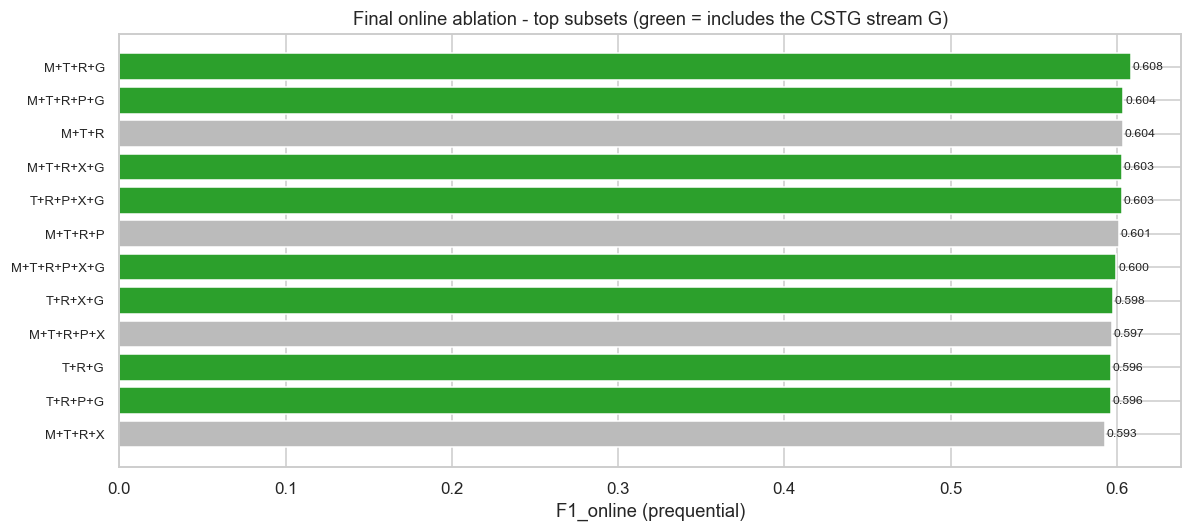

In [3]:
import pickle
ABL = pickle.load(open(ROOT/'outputs/online_jit_ablation_v3.pkl','rb'))
rows = [(lab, 'G' in lab.split('+'), v['cum']['F1_online'], v['cum']['PR_AUC'], v['cum']['ROC_AUC'])
        for lab, v in ABL.items()]
adf = pd.DataFrame(rows, columns=['subset','has_G','F1_online','PR_AUC','ROC']).sort_values('F1_online', ascending=False)
display(adf.head(12).round(3))
def get(lab):
    for l, v in ABL.items():
        if set(l.split('+')) == set(lab.split('+')): return v['cum']
b = get('M+T+R+P'); f = get('M+T+R+P+G')
if b and f:
    print(f"M+T+R+P   (KG):      ROC {b['ROC_AUC']:.3f}  PR {b['PR_AUC']:.3f}  F1_on {b['F1_online']:.3f}")
    print(f"M+T+R+P+G (KG+CSTG): ROC {f['ROC_AUC']:.3f}  PR {f['PR_AUC']:.3f}  F1_on {f['F1_online']:.3f}")
top = adf.head(12)
plt.figure(figsize=(11, 5))
colors = ['#2CA02C' if g else '#BBBBBB' for g in top['has_G']]
plt.barh(range(len(top)), top['F1_online'], color=colors, edgecolor='white')
for i, v in enumerate(top['F1_online']): plt.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.yticks(range(len(top)), top['subset'], fontsize=8.5); plt.gca().invert_yaxis()
plt.xlabel('F1_online (prequential)')
plt.title('Final online ablation - top subsets (green = includes the CSTG stream G)')
plt.tight_layout(); plt.show()

### 8c. Baselines vs KG-v1 vs KG-v2 vs KG-v3 (final)

The V2 comparison extended with the **V3 CSTG layer (G)**: G alone, and the CSTG fused into the KG (M+T+R+G, M+T+R+P+G). Same fully-online protocol; dashed line = best JIT-metric baseline.

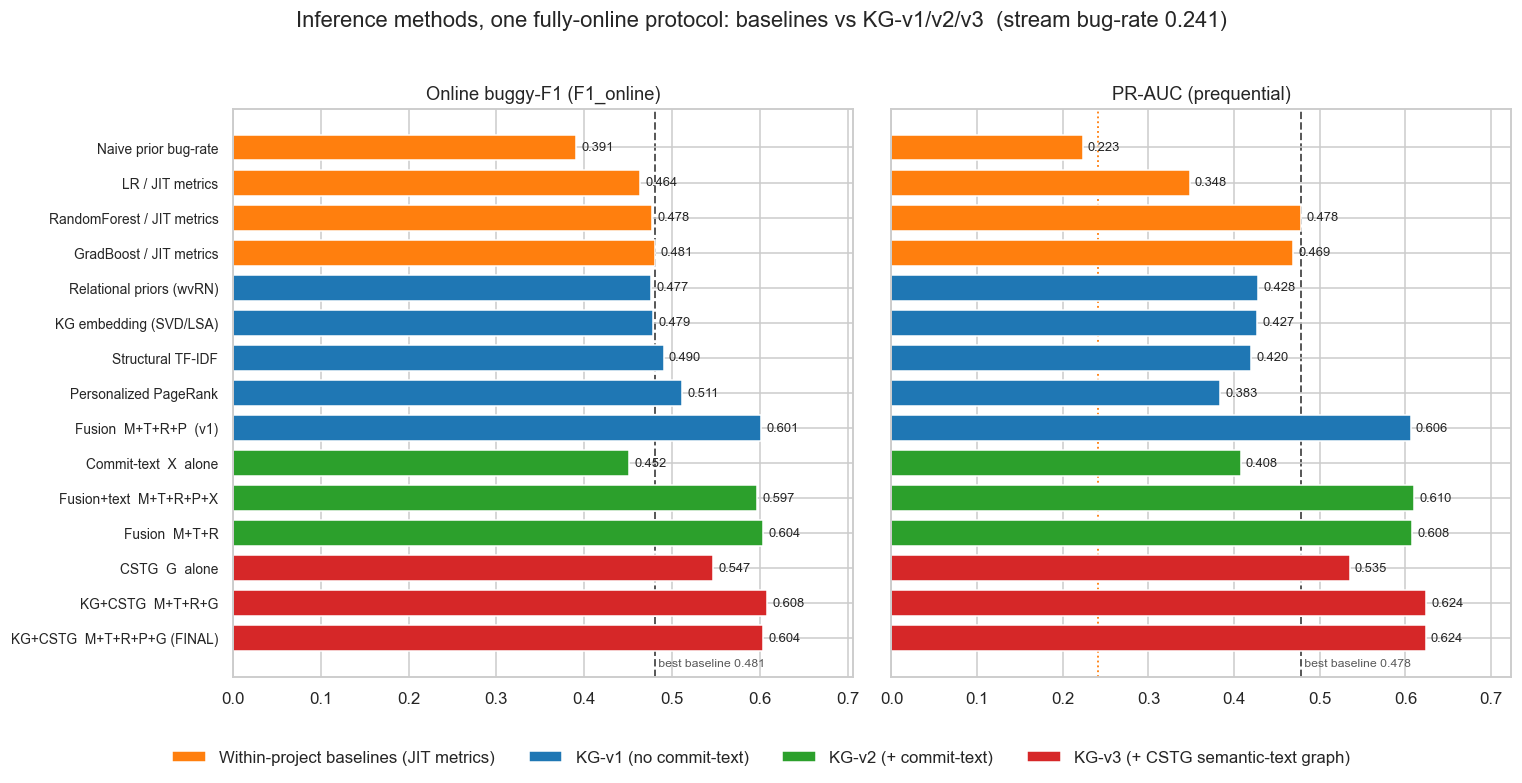

best baseline F1_on=0.481 | v1 Fusion=0.601 | v2 M+T+R=0.604 | v3 M+T+R+P+G=0.604


In [5]:
import pickle, sys
sys.path.insert(0, str(ROOT/'inference')); import online_jit as oj
from matplotlib.patches import Patch
R   = pickle.load(open(ROOT/'outputs/online_jit_results.pkl','rb'))
ABL = pickle.load(open(ROOT/'outputs/online_jit_ablation_v3.pkl','rb'))
KGBLUE, KGGREEN, KGORANGE, KGRED = '#1F77B4', '#2CA02C', '#FF7F0E', '#D62728'
M = {v['name']: v['cum'] for v in R['methods'].values()}
g = lambda n: (M[n]['F1_online'], M[n]['PR_AUC'])
a = lambda l: (ABL[l]['cum']['F1_online'], ABL[l]['cum']['PR_AUC'])
ROWS = [
    ('Naive prior bug-rate',        g('Naive prior bug-rate'),            'base'),
    ('LR / JIT metrics',            g('LR / JIT metrics (incremental)'),  'base'),
    ('RandomForest / JIT metrics',  g('RandomForest / JIT metrics'),      'base'),
    ('GradBoost / JIT metrics',     g('GradBoost / JIT metrics'),         'base'),
    ('Relational priors (wvRN)',    g('Relational priors (wvRN)'),        'v1'),
    ('KG embedding (SVD/LSA)',      g('KG embedding (SVD/LSA)'),          'v1'),
    ('Structural TF-IDF',           g('Structural TF-IDF (incremental)'), 'v1'),
    ('Personalized PageRank',       g('Personalized PageRank'),           'v1'),
    ('Fusion  M+T+R+P  (v1)',       a('M+T+R+P'),                         'v1'),
    ('Commit-text  X  alone',       a('X'),                               'v2'),
    ('Fusion+text  M+T+R+P+X',      a('M+T+R+P+X'),                       'v2'),
    ('Fusion  M+T+R',               a('M+T+R'),                           'v2'),
    ('CSTG  G  alone',              a('G'),                               'v3'),
    ('KG+CSTG  M+T+R+G',            a('M+T+R+G'),                         'v3'),
    ('KG+CSTG  M+T+R+P+G (FINAL)',  a('M+T+R+P+G'),                       'v3'),
]
COLOR  = {'base':KGORANGE, 'v1':KGBLUE, 'v2':KGGREEN, 'v3':KGRED}
LEGEND = {'base':'Within-project baselines (JIT metrics)', 'v1':'KG-v1 (no commit-text)',
          'v2':'KG-v2 (+ commit-text)', 'v3':'KG-v3 (+ CSTG semantic-text graph)'}
order = sum(([r for r in ROWS if r[2]==k] for k in ('base','v1','v2','v3')), [])
labels=[r[0] for r in order]; f1=np.array([r[1][0] for r in order]); pr=np.array([r[1][1] for r in order])
colors=[COLOR[r[2]] for r in order]; y=np.arange(len(order))
best_f1=max(r[1][0] for r in ROWS if r[2]=='base'); best_pr=max(r[1][1] for r in ROWS if r[2]=='base')
stream_bug=R['meta']['stream_bug']
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
for ax, vals, title, ref in [(axes[0], f1, 'Online buggy-F1 (F1_online)', best_f1),
                             (axes[1], pr, 'PR-AUC (prequential)', best_pr)]:
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.74)
    ax.axvline(ref, ls='--', lw=1.3, color='0.35', zorder=0)
    ax.text(ref, len(order)-0.3, f' best baseline {ref:.3f}', color='0.35', fontsize=8, va='center')
    for yi, v in zip(y, vals): ax.text(v+0.006, yi, f'{v:.3f}', va='center', fontsize=8.5)
    ax.set_xlim(0, vals.max()*1.16); ax.set_title(title); ax.set_axisbelow(True)
axes[1].axvline(stream_bug, ls=':', lw=1.2, color=KGORANGE, zorder=0)
axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=9); axes[0].invert_yaxis()
fig.legend(handles=[Patch(facecolor=COLOR[k], label=LEGEND[k]) for k in ('base','v1','v2','v3')],
           loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Inference methods, one fully-online protocol: baselines vs KG-v1/v2/v3  (stream bug-rate {stream_bug:.3f})')
plt.tight_layout(rect=[0, 0.05, 1, 0.96]); plt.show()
print('best baseline F1_on=%.3f | v1 Fusion=%.3f | v2 M+T+R=%.3f | v3 M+T+R+P+G=%.3f'
      % (best_f1, ABL['M+T+R+P']['cum']['F1_online'], ABL['M+T+R']['cum']['F1_online'], ABL['M+T+R+P+G']['cum']['F1_online']))

### 8d. Online stream: single features vs full fusion (with CSTG)

Rolling prequential PR-AUC as commits arrive, for each single feature (M,T,R,P,X,**G**) and the full **M+T+R+P+X+G** fusion. The full fusion stays on top throughout the stream.

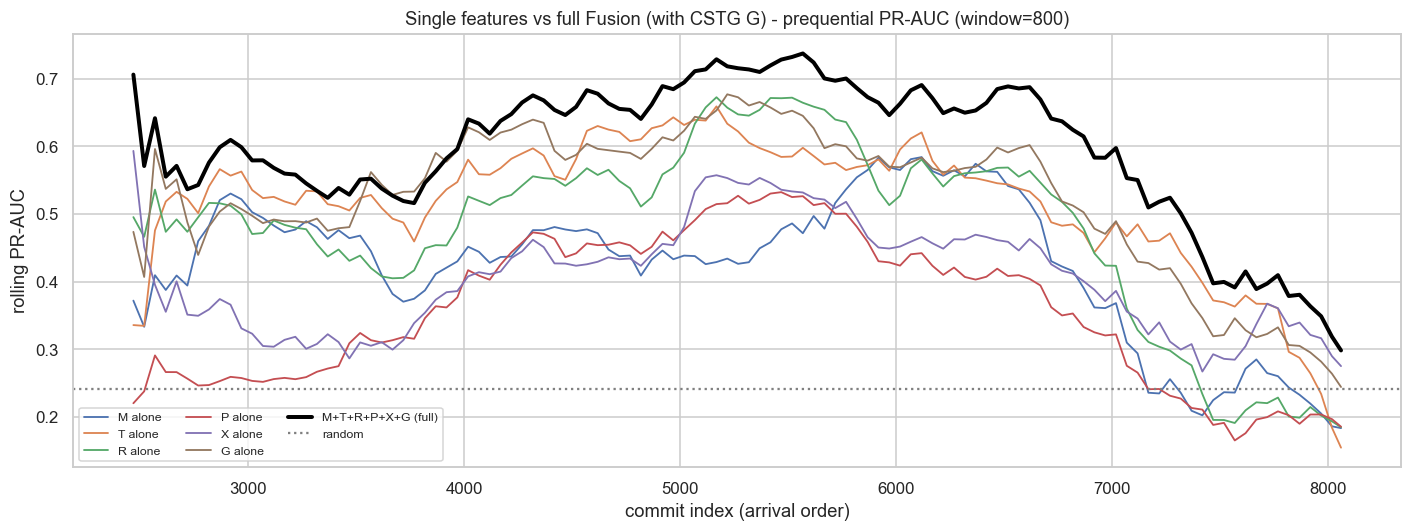

In [6]:
import pickle, sys
sys.path.insert(0, str(ROOT/'inference')); import online_jit as oj
ABL = pickle.load(open(ROOT/'outputs/online_jit_ablation_v3.pkl','rb'))
R   = pickle.load(open(ROOT/'outputs/online_jit_results.pkl','rb'))
FULL = '+'.join(oj.FEAT_ABBR[f] for f in oj.FEATURES)   # M+T+R+P+X+G
fig, ax = plt.subplots(figsize=(13, 5))
for f in oj.FEATURES:
    t = ABL[oj.FEAT_ABBR[f]]['traj']
    ax.plot(t['idx'], t['PR_AUC'], lw=1.2, label=oj.FEAT_ABBR[f]+' alone')
t = ABL[FULL]['traj']; ax.plot(t['idx'], t['PR_AUC'], lw=2.6, color='black', label=FULL+' (full)')
ax.axhline(R['meta']['stream_bug'], ls=':', c='gray', label='random')
ax.set(xlabel='commit index (arrival order)', ylabel='rolling PR-AUC',
       title='Single features vs full Fusion (with CSTG G) - prequential PR-AUC (window=800)')
ax.legend(fontsize=8, ncol=3); plt.tight_layout(); plt.show()

### 8e. Comprehensive operating-point metrics (Precision, Recall, Buggy-F1, Macro-F1, G-Mean, MCC)

For the imbalanced JIT task the deployment story is the operating-point metrics at the online-tuned threshold. **MCC** and **Macro-F1**/**G-Mean** are the most reliable under imbalance. Post-hoc from stored (y,p).

In [ ]:
import pickle, sys
sys.path.insert(0, str(ROOT/'inference')); import stream_metrics as sm
R = pickle.load(open(ROOT/'outputs/online_jit_results.pkl','rb'))
ABL = pickle.load(open(ROOT/'outputs/online_jit_ablation_v3.pkl','rb'))
Mn = {v['name']: v for v in R['methods'].values()}
def row(src):
    f = sm.final_metrics(src['y'], src['p']); c = src['cum']
    return [f['precision'], f['recall'], f['buggy_f1'], f['macro_f1'], f['gmean'], f['mcc'], c['ROC_AUC'], c['PR_AUC']]
SPEC = [('LR / JIT metrics','base','R','LR / JIT metrics (incremental)'),
        ('RF / JIT metrics','base','R','RandomForest / JIT metrics'),
        ('GBM / JIT metrics','base','R','GradBoost / JIT metrics'),
        ('wvRN priors','v1','R','Relational priors (wvRN)'),
        ('Structural TF-IDF','v1','R','Structural TF-IDF (incremental)'),
        ('KG embedding (SVD)','v1','R','KG embedding (SVD/LSA)'),
        ('Fusion M+T+R+P (v1)','v1','A','M+T+R+P'),
        ('Fusion+text M+T+R+P+X (v2)','v2','A','M+T+R+P+X'),
        ('Fusion M+T+R (v2)','v2','A','M+T+R'),
        ('CSTG G alone (v3)','v3','A','G'),
        ('KG+CSTG M+T+R+G (v3)','v3','A','M+T+R+G'),
        ('KG+CSTG M+T+R+P+G (FINAL)','v3','A','M+T+R+P+G')]
recs, grps = [], []
for nm,grp,kind,key in SPEC:
    src = Mn[key] if kind=='R' else ABL[key]
    recs.append([nm]+row(src)); grps.append(grp)
df = pd.DataFrame(recs, columns=['method','Precision','Recall','Buggy-F1','Macro-F1','G-Mean','MCC','ROC','PR-AUC']).set_index('method')
display(df.round(3))
COL={'base':'#FF7F0E','v1':'#1F77B4','v2':'#2CA02C','v3':'#D62728'}; colors=[COL[g] for g in grps]
fig,ax=plt.subplots(1,3,figsize=(15,5),sharey=True); yy=np.arange(len(df))
for a,m in zip(ax,['Buggy-F1','Macro-F1','G-Mean']):
    a.barh(yy, df[m], color=colors, edgecolor='white')
    for i,v in enumerate(df[m]): a.text(v+0.004,i,f'{v:.3f}',va='center',fontsize=8)
    a.set_title(m+' (online)'); a.set_xlim(0, df[m].max()*1.18); a.grid(axis='x',ls=':',alpha=.5)
ax[0].set_yticks(yy); ax[0].set_yticklabels(df.index,fontsize=8.5); ax[0].invert_yaxis()
plt.suptitle('Operating-point imbalance metrics, fully-online protocol'); plt.tight_layout(); plt.show()

### 8f. Online stream trends of the operating-point metrics

Rolling Precision / Recall / Buggy-F1 / Macro-F1 / G-Mean / MCC (window=800, online threshold) as commits arrive. KG+CSTG leads on the balanced metrics throughout; the JIT baseline trades precision for recall in the tail.

In [ ]:
series = [('JIT metrics (M)','M','#FF7F0E','-'), ('KG fusion M+T+R+P','M+T+R+P','#1F77B4','-'),
          ('CSTG G','G','#2CA02C','--'), ('KG+CSTG M+T+R+P+G','M+T+R+P+G','#D62728','-')]
trends = [(nm, sm.rolling(ABL[lab]['y'], ABL[lab]['p'], window=800), c, ls) for nm,lab,c,ls in series]
panels = [('precision','Precision'),('recall','Recall'),('buggy_f1','Buggy-F1'),('macro_f1','Macro-F1'),('gmean','G-Mean'),('mcc','MCC')]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for a,(key,t) in zip(axes.ravel(), panels):
    for nm, tr, c, ls in trends:
        a.plot(tr['idx'], tr[key], ls, color=c, lw=2.6 if 'P+G' in nm else 1.6, label=nm)
    a.set(xlabel='commit index (arrival order)', ylabel='rolling '+t, title='Online '+t+' trend (window=800)'); a.grid(ls=':',alpha=.5)
axes[0,0].legend(fontsize=8, loc='lower left')
plt.suptitle('Online (prequential) operating-point metric trends as commits arrive', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

## 7. Notes
* This is a **single streaming pass**: each commit is predicted once (before the
  model ever sees it), then used to grow the KG and update every learner — no
  look-ahead leakage anywhere.
* Linear models learn **incrementally** (`partial_fit`); tree/fusion/embedding
  models are **retrained on the expanding past window** periodically; graph
  features (PPR, SVD embedding) are **refreshed over the past-only graph**.
* Compare with the blocked/offline evaluation in `inference_results.ipynb` and
  the controlled same-split baseline comparison in `inference/compare_baselines.py`.